## Carregamento da base

In [ ]:
#Carregamento da base
import pandas as pd

df = pd.read_csv(r"C:\Users\SarahCavalcanteSalvi\Desktop\PROJETOS\varejo_brasil_long.csv")
df.head(50)

,transacao_id,item
0,1,atum enlatado
1,1,cerveja lata
2,1,geleia
3,1,legumes congelados
4,1,leite integral
5,1,manteiga
6,1,pão francês
7,2,arroz
8,2,cerveja long neck
9,2,frango


## Análise exploratória

In [20]:
#Descrição da base de dados
df.describe()

,transacao_id
count,74138.000000
mean,4897.383245
std,2838.598122
min,1.000000
25%,2431.000000
50%,4893.000000
75%,7351.000000
max,9835.000000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74138 entries, 0 to 74137
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   transacao_id  74138 non-null  int64
 1   item          74138 non-null  str  
dtypes: int64(1), str(1)
memory usage: 2.0 MB


In [22]:
df.isnull().sum()

transacao_id    0
item            0
dtype: int64

In [23]:
#Verificando a quantidade de valores únicos em cada coluna
df.nunique()

transacao_id    9835
item              97
dtype: int64

In [24]:
#Verificando mais detalhado os valores únicos da coluna 'item'
df['item'].unique()

<ArrowStringArray>
[           'atum enlatado',             'cerveja lata',
                   'geleia',       'legumes congelados',
           'leite integral',                 'manteiga',
              'pão francês',                    'arroz',
        'cerveja long neck',                   'frango',
         'frutas tropicais',           'outros legumes',
             'pão integral',           'fermento em pó',
         'leite condensado',                     'ovos',
             'cream cheese',             'carne bovina',
          'frutas cítricas',                 'salsicha',
       'artigos de higiene',                   'açúcar',
                     'café',           'cereal matinal',
  'extrato/polpa de tomate',                    'sopas',
               'absorvente',         'frutas vermelhas',
                 'macarrão',          'queijo parmesão',
         'vinho tinto/rosé',            'suco de fruta',
           'jornal/revista',               'limpa-vaso',
            

In [25]:
#Verificando o item que mais se repete na coluna 'item'
df["item"].value_counts().idxmax()

'leite integral'

In [26]:
#Verificando a quantidade de transações por item do maior para o menor
df.groupby("item")["transacao_id"].count().sort_values(ascending=False)

item
leite integral         3352
outros legumes         2647
pão francês            2504
refrigerante           2120
iogurte                1842
                       ... 
cosméticos infantis     112
vinagre                 101
destilados              101
peru                     98
mostarda                 95
Name: transacao_id, Length: 97, dtype: int64

In [27]:
#Verificando quantos % representa do total de itens vendidos
soma_itens = df.groupby("item")["transacao_id"].sum().sort_values(ascending=False)
print((soma_itens / soma_itens.sum() * 100).round(2))

item
leite integral         4.47
outros legumes         3.56
pão francês            3.33
refrigerante           2.86
iogurte                2.46
                       ... 
destilados             0.14
vinagre                0.14
cosméticos infantis    0.14
peru                   0.13
mostarda               0.12
Name: transacao_id, Length: 97, dtype: float64


Text(0.5, 1.0, '30 Produtos mais vendidos')

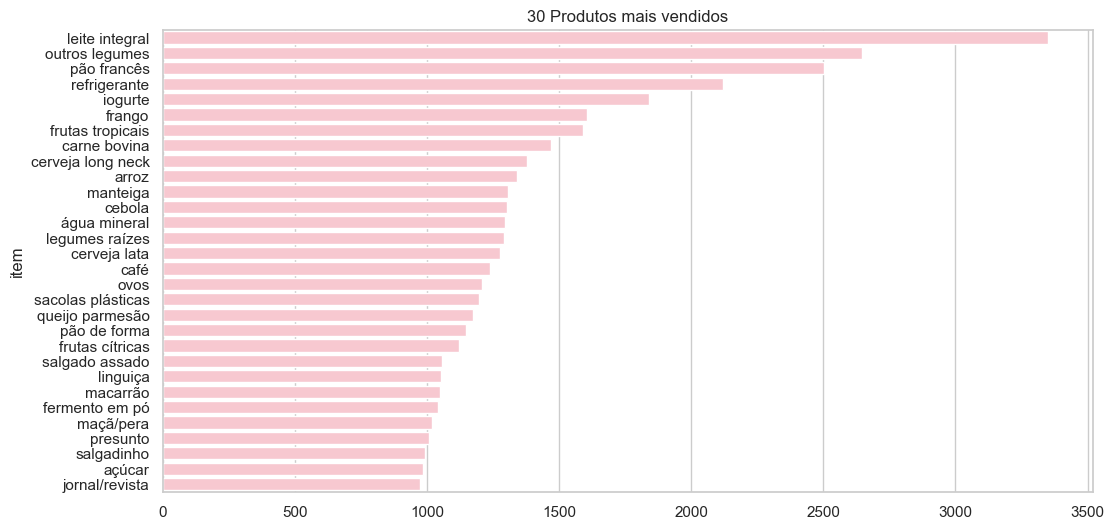

In [28]:
#Importação das bibliotecas para gráfico
import matplotlib.pyplot as plt
import seaborn as sns

#Gráfico dos 30 produtos mais vendidos
produtos_mais_vendidos = df.groupby("item")["transacao_id"].count().sort_values(ascending=False).head(30)
plt.figure(figsize=(12,6))
sns.barplot(x=produtos_mais_vendidos.values, y=produtos_mais_vendidos.index, color="pink")
plt.title("30 Produtos mais vendidos")


## Aplicação do modelo

In [29]:
#Importando bibliotecas para análise de associação com Apriori e mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

#Criando uma lista de transações, onde cada transação é uma lista de itens comprados juntos
transacoes_lista = df.groupby('transacao_id')['item'].apply(list).tolist()
print(f"Total de transações: {len(transacoes_lista)}")

Total de transações: 9835


In [30]:
transacoes_lista

[['atum enlatado',
  'cerveja lata',
  'geleia',
  'legumes congelados',
  'leite integral',
  'manteiga',
  'pão francês'],
 ['arroz',
  'cerveja long neck',
  'frango',
  'frutas tropicais',
  'leite integral',
  'outros legumes',
  'pão integral'],
 ['fermento em pó', 'leite condensado', 'ovos'],
 ['cream cheese', 'leite integral'],
 ['arroz',
  'carne bovina',
  'frutas cítricas',
  'leite integral',
  'manteiga',
  'outros legumes',
  'salsicha'],
 ['artigos de higiene',
  'açúcar',
  'café',
  'cereal matinal',
  'extrato/polpa de tomate',
  'leite integral',
  'pão integral',
  'sopas'],
 ['absorvente',
  'artigos de higiene',
  'frango',
  'frutas vermelhas',
  'macarrão',
  'outros legumes',
  'queijo parmesão',
  'salsicha',
  'vinho tinto/rosé'],
 ['açúcar',
  'cerveja long neck',
  'extrato/polpa de tomate',
  'macarrão',
  'outros legumes',
  'queijo parmesão',
  'suco de fruta'],
 ['extrato/polpa de tomate',
  'frango',
  'jornal/revista',
  'limpa-vaso',
  'manteiga',
  

In [31]:
#Preparando os dados usando TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transacoes_lista).transform(transacoes_lista)
df_preparado = pd.DataFrame(te_ary, columns=te.columns_)

df_preparado.head()

,absorvente,adoçante,amaciante,arroz,artigos de higiene,atum enlatado,açúcar,balas e doces,batata congelada,biscoito cream cracker,...,sorvete,suco de fruta,temperos frescos,uva,vinagre,vinho branco,vinho tinto/rosé,vitaminas e suplementos,água mineral,óleo de cozinha
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Encontrando padrões frequentes (suporte mínimo de 50 transações)
padroes = apriori(df_preparado, min_support=0.005, use_colnames=True)

#Gerando as regras com confiança mínima de 50%
todas_as_regras = association_rules(padroes, metric="confidence", min_threshold=0.5)

#Filtrando apenas regras com Lift > 1 (associações genuínas)
regras_filtradas = todas_as_regras[todas_as_regras['lift'] > 1].sort_values(by='lift', ascending=False)

print(f"Total de padrões encontrados: {len(padroes)}")
print(f"Total de regras com Lift > 1: {len(regras_filtradas)}")

Total de padrões encontrados: 3133
Total de regras com Lift > 1: 234


In [33]:
#Imprimindo os padrões encontrados e as regras filtradas
visao_regras = regras_filtradas[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
visao_regras.head(10)

,antecedents,consequents,support,confidence,lift
32,"frozenset({legumes congelados, batata congelada})",frozenset({frango congelado}),0.015862,0.891429,15.655714
30,"frozenset({frango congelado, legumes congelados})",frozenset({batata congelada}),0.015862,0.852459,15.383366
79,"frozenset({papel higiênico, detergente})",frozenset({produto de limpeza}),0.016472,0.525974,12.647811
211,"frozenset({papel higiênico, detergente, leite ...",frozenset({produto de limpeza}),0.005694,0.513761,12.354142
80,"frozenset({produto de limpeza, detergente})",frozenset({papel higiênico}),0.016472,0.920455,12.022139
212,"frozenset({produto de limpeza, leite integral,...",frozenset({papel higiênico}),0.005694,0.903226,11.797113
69,"frozenset({chantilly, chocolate})",frozenset({leite condensado}),0.015353,0.825137,11.255504
78,"frozenset({papel higiênico, produto de limpeza})",frozenset({detergente}),0.016472,0.905028,10.881357
210,"frozenset({papel higiênico, produto de limpeza...",frozenset({detergente}),0.005694,0.903226,10.859689
219,"frozenset({fermento em pó, outros legumes, man...",frozenset({farinha de trigo}),0.005287,0.866667,10.135157


## Conclusão: Análise de Regras de Associação (Apriori)

A aplicação do algoritmo **Apriori** sobre o histórico de **9.835 transações** permitiu mapear com precisão o comportamento de compra dos clientes, transformando dados brutos em inteligência de mercado. A filtragem estratégica adotada (Suporte Mínimo Absoluto de 50 repetições, Confiança acima de 50% e **Lift > 1**) gerou **3.133 padrões frequentes**, refinados para **234 regras de associação legítimas** e acionáveis.

A análise do topo do ranking revelou três grandes pilares de comportamento:

* **Altíssima Interdependência de Categorias:** O maior destaque do estudo foi o combo de conveniência alimentar. A associação entre `legumes congelados + batata congelada` e o `frango congelado` atingiu um **Lift de 15.66** e **89,14% de confiança**. Isso prova que esses produtos não são comprados de forma isolada, mas sim como uma solução completa de refeição.
* **Comportamento de Abastecimento Logístico:** A força das regras ligadas ao setor de higiene e limpeza (como o combo de `produto de limpeza + detergente` engajando a compra de `papel higiênico` com **92,04% de confiança** e **Lift de 12.02**) indica que o cliente, quando decide abastecer a área de serviço, tende a levar a categoria inteira.
* **Gatilhos de Impulso Específicos:** Associações sazonais ou de nicho, como `chantilly + chocolate` impulsionando o `leite condensado` (**Lift de 11.26**), mapeiam perfeitamente os hábitos voltados a momentos de indulgência e sobremesas.


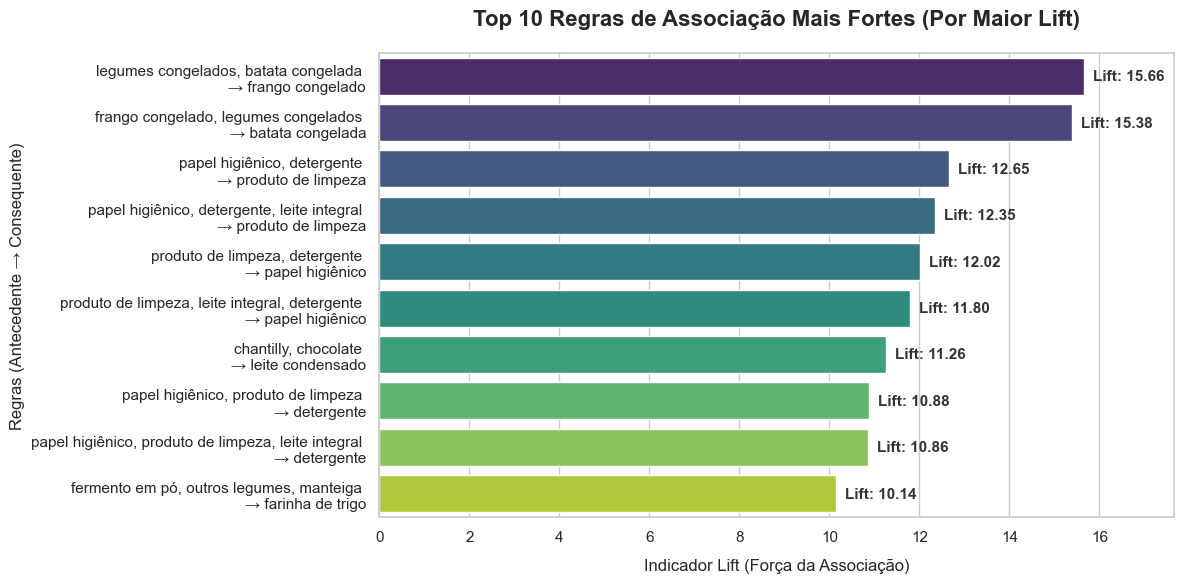

In [ ]:
#Importando bibliotecas para visualização das regras de associação
import matplotlib.pyplot as plt
import seaborn as sns

#Selecionando as 10 regras mais fortes (maior lift)
top_10_regras = regras_filtradas.sort_values(by='lift', ascending=False).head(10).copy()

#Exibindo as regras de forma mais legível (antecedente → consequente)
top_10_regras['regra'] = top_10_regras.apply(
    lambda row: f"{', '.join(list(row['antecedents']))} \n→ {', '.join(list(row['consequents']))}", 
    axis=1
)

#Configurando o estilo do gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

#Criando o gráfico de barras
grafico = sns.barplot(
    x='lift', 
    y='regra', 
    data=top_10_regras, 
    palette='viridis',
    hue='regra',
    legend=False
)

#Adicionando os valores exatos do Lift na ponta de cada barra
for i, barra in enumerate(grafico.patches):
    lift_valor = top_10_regras['lift'].iloc[i]
    grafico.text(
        barra.get_width() + 0.2, 
        barra.get_y() + barra.get_height()/2, 
        f"Lift: {lift_valor:.2f}", 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

#Ajustando títulos e eixos
plt.title('Top 10 Regras de Associação Mais Fortes (Por Maior Lift)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Indicador Lift (Força da Associação)', fontsize=12, labelpad=10)
plt.ylabel('Regras (Antecedente → Consequente)', fontsize=12)
plt.xlim(0, top_10_regras['lift'].max() + 2) # Dá um espaço no final para o texto não cortar

#Exibindo o gráfico limpo
plt.tight_layout()
plt.show()